<h1 align ='center'>Importing Libraries </h1>

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,random_split
from torchvision import datasets, transforms
import torchvision.models as models
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import Literal
import numpy as np
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

<h1 align ='center'>Dataset Loading</h1>

In [3]:
# Dataset Augmentation
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [4]:
# Loading dataaset
dataset = datasets.ImageFolder(
    root='FreshHarvest_Dataset/FRUIT-16K',
    transform = image_transforms)

In [5]:
# STotal No. of Images
len(dataset)

16000

In [6]:
# Classes
dataset.classes

['F_Banana',
 'F_Lemon',
 'F_Lulo',
 'F_Mango',
 'F_Orange',
 'F_Strawberry',
 'F_Tamarillo',
 'F_Tomato',
 'S_Banana',
 'S_Lemon',
 'S_Lulo',
 'S_Mango',
 'S_Orange',
 'S_Strawberry',
 'S_Tamarillo',
 'S_Tomato']

In [7]:
# Dataset Splitting
train_size = int(0.75*len(dataset))
test_val_size = len(dataset) - train_size
val_size = int(0.75*test_val_size)
test_size = test_val_size-val_size

train_dataset,test_val_dataset = random_split(dataset,[train_size,test_val_size])
val_dataset,test_dataset = random_split(test_val_dataset,[val_size,test_size])

len(train_dataset), len(val_dataset), len(test_dataset)

(12000, 3000, 1000)

In [8]:
train_loader = DataLoader(train_dataset, batch_size = 64,shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = True)

In [9]:
len(train_loader)

188

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


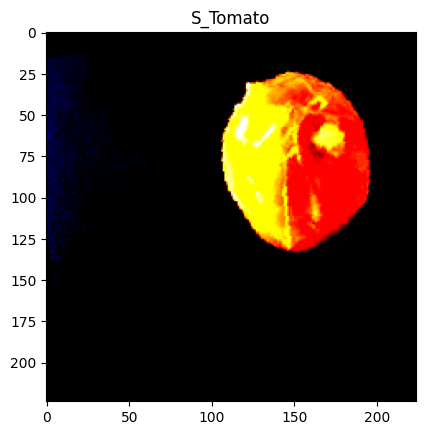

In [10]:
for image,label in train_loader:
    plt.imshow(image[0].permute(1,2,0))
    plt.title(dataset.classes[label[0].item()])
    break

<h1 align ='center'> Model Training </h1>

### Training Function and Early Stopping Implementation

In [11]:
class EarlyStopping:
    def __init__(self, patience:int, min_delta:float, mode: Literal['min','max'], checkpoint_path:str) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode.lower()
        self.checkpoint_path = checkpoint_path

        self.counter = 0

        if self.mode == 'min':
            self.best_score = np.inf
            self.is_better = lambda current_score, best_score: current_score < (best_score - self.min_delta)
            
        elif self.mode == 'max':
            self.best_score = -np.inf
            self.is_better = lambda current_score, best_score: current_score > (best_score + self.min_delta)
            
        else:
            raise ValueError("Mode must either be 'min' or 'max'")

    def __call__(self,current_score:float, model:torch.nn.Module) -> bool:
        if self.is_better:
            print(f"Metric improved ({self.best_score:.4f} --> {current_score:.4f}). Saving model weights...")
            self.best_score = current_score
            counter = 0
            self.save_checkpoint(model)
            return False
        else:
            self.counter +=1
            print(f"No significant improvement. Early stopping counter: {self.counter}")
            if self.counter >= self.patience:
                return True

    def save_checkpoint(self, model:torch.nn.Module):
        torch.save(model.state_dict(), self.checkpoint_path)

In [12]:
def train_validate(model,criterion,optimizer,num_epochs,early_stop = None):
    train_accuracies, val_accuracies = [], []
    for epoch in range(num_epochs):
        running_loss = 0.0
        train_true_labels, train_pred_labels, = [],[]
        model.train()
        for batch, (images, labels) in enumerate(train_loader):
            images,labels = images.to(device), labels.to(device)
            # 1. Forward Pass
            optimizer.zero_grad()
            output = model(images) 
            loss = criterion(output,labels)
            running_loss+= loss.item()*images.size(0)
            
            # 2. Backward Pass
            loss.backward()
            
            # 3. Updating parameters
            optimizer.step()

            # logging labels
            _,train_predicted = torch.max(output.data,1)
            train_true_labels.extend(labels.cpu().numpy())
            train_pred_labels.extend(train_predicted.cpu().numpy())

                    
            if (batch+1)%20 == 0:
                print(f"Batch: {batch+1} | Epoch: {epoch+1} | Loss: {loss.item():.2f}")
            
        train_accuracies.append(accuracy_score(train_true_labels,train_pred_labels))
    

        model.eval()
        val_true_labels,val_pred_labels= [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                _, predicted = torch.max(output.data, 1) 
                val_true_labels.extend(labels.cpu().numpy())
                val_pred_labels.extend(predicted.cpu().numpy())

        epoch_loss = running_loss/len(train_loader.dataset)
        val_accuracy = accuracy_score(val_true_labels,val_pred_labels)
        val_accuracies.append(val_accuracy)
        print(f"Epoch: {epoch+1} | Average Training Loss: {epoch_loss:.2f}")
        if early_stop is not None:
            if early_stop(val_accuracy,model):
                break
        print(f"Validation Accuracy: {100*(val_accuracy):.2f}%")
    
    return train_accuracies, val_accuracies  

### Training a Base CNN

In [13]:
class FreshnessClassifier(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            # First Convolution Layer
            nn.Conv2d(in_channels=3, out_channels= 16, stride=1, kernel_size =3, padding='same'), #(3,224,224) -> (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride = 2, padding=0), # (16,224,224) -> (16,112,112)

            # Second Convolution Layer
            nn.Conv2d(in_channels= 16, out_channels = 32, stride = 1, kernel_size =3, padding = 'same'), #(16,112,112) -> (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride = 2, padding = 0), #(32,112,112) -> (32,56,56)

            # Third Convolution Layer
            nn.Conv2d(in_channels = 32, out_channels=64, stride =1, kernel_size =3, padding = 'same'), #(32,56, 56) -> (64, 56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride = 2, padding = 0), # (64,56,56) ==> (64,28,28)

            # Fully Connected Layer
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        return self.network(x)
        

In [14]:
num_classes = len(dataset.classes)
early_stop = EarlyStopping(patience = 5, min_delta = 0.01, mode = 'max', checkpoint_path = './artifacts/base_cnn_model.pth')
base_model = FreshnessClassifier(num_classes).to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(base_model.parameters(),lr = 0.002)

In [15]:
train_accuracies, val_accuracies = train_validate(base_model,criterion,optimizer,10,early_stop)

Batch: 20 | Epoch: 1 | Loss: 2.66
Batch: 40 | Epoch: 1 | Loss: 2.43
Batch: 60 | Epoch: 1 | Loss: 2.44
Batch: 80 | Epoch: 1 | Loss: 2.04
Batch: 100 | Epoch: 1 | Loss: 1.96
Batch: 120 | Epoch: 1 | Loss: 1.99
Batch: 140 | Epoch: 1 | Loss: 1.31
Batch: 160 | Epoch: 1 | Loss: 1.47
Batch: 180 | Epoch: 1 | Loss: 1.36
Epoch: 1 | Average Training Loss: 2.03
Metric improved (-inf --> 0.4990). Saving model weights...
Validation Accuracy: 49.90%
Batch: 20 | Epoch: 2 | Loss: 1.16
Batch: 40 | Epoch: 2 | Loss: 1.20
Batch: 60 | Epoch: 2 | Loss: 1.18
Batch: 80 | Epoch: 2 | Loss: 1.08
Batch: 100 | Epoch: 2 | Loss: 1.06
Batch: 120 | Epoch: 2 | Loss: 1.24
Batch: 140 | Epoch: 2 | Loss: 1.33
Batch: 160 | Epoch: 2 | Loss: 1.26
Batch: 180 | Epoch: 2 | Loss: 1.40
Epoch: 2 | Average Training Loss: 1.20
Metric improved (0.4990 --> 0.5457). Saving model weights...
Validation Accuracy: 54.57%
Batch: 20 | Epoch: 3 | Loss: 0.78
Batch: 40 | Epoch: 3 | Loss: 0.92
Batch: 60 | Epoch: 3 | Loss: 0.99
Batch: 80 | Epoch: 3 |

### Evaluation of Base CNN

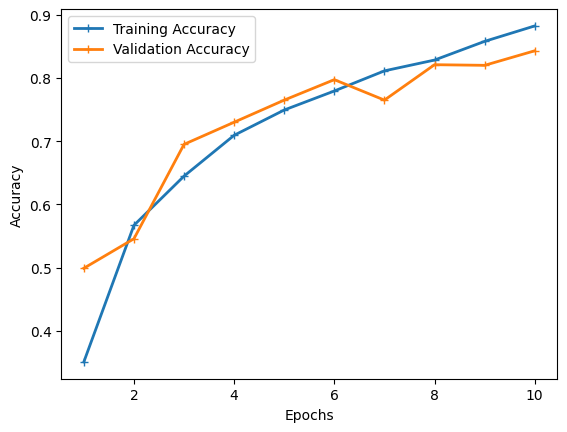

In [16]:
plt.plot(range(1,11,1), train_accuracies,label= "Training Accuracy",marker= '+',linewidth = 2)
plt.plot(range(1,11,1), val_accuracies, label = "Validation Accuracy",marker = '+',linewidth = 2)
plt.xlabel('Epochs')
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [17]:
num_classes = len(dataset.classes)
trained_base_model = FreshnessClassifier(num_classes =num_classes ).to(device)
trained_base_model.load_state_dict(torch.load("./artifacts/base_cnn_model.pth"))

<All keys matched successfully>

In [18]:
true_labels, predicted_labels = [],[]
for images,labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    output = trained_base_model(images)
    _, predicted = torch.max(output.data,dim =1)
    true_labels.extend(labels.cpu().numpy())
    predicted_labels.extend(predicted.cpu().numpy())
else:
    print("All the labels are stored...")

All the labels are stored...


In [19]:
report = classification_report(true_labels,predicted_labels)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.93      0.87        70
           1       0.88      0.95      0.91        55
           2       0.96      0.93      0.95        58
           3       0.77      0.72      0.75        61
           4       0.94      0.86      0.90        57
           5       0.80      0.68      0.74        63
           6       0.75      0.97      0.85        66
           7       0.68      0.83      0.75        60
           8       0.90      0.81      0.86        80
           9       0.89      0.91      0.90        64
          10       0.89      0.93      0.91        55
          11       0.72      0.74      0.73        62
          12       0.94      0.92      0.93        63
          13       0.88      0.76      0.81        49
          14       0.70      0.69      0.70        58
          15       0.83      0.68      0.75        79

    accuracy                           0.83      1000
   macro avg       0.84   

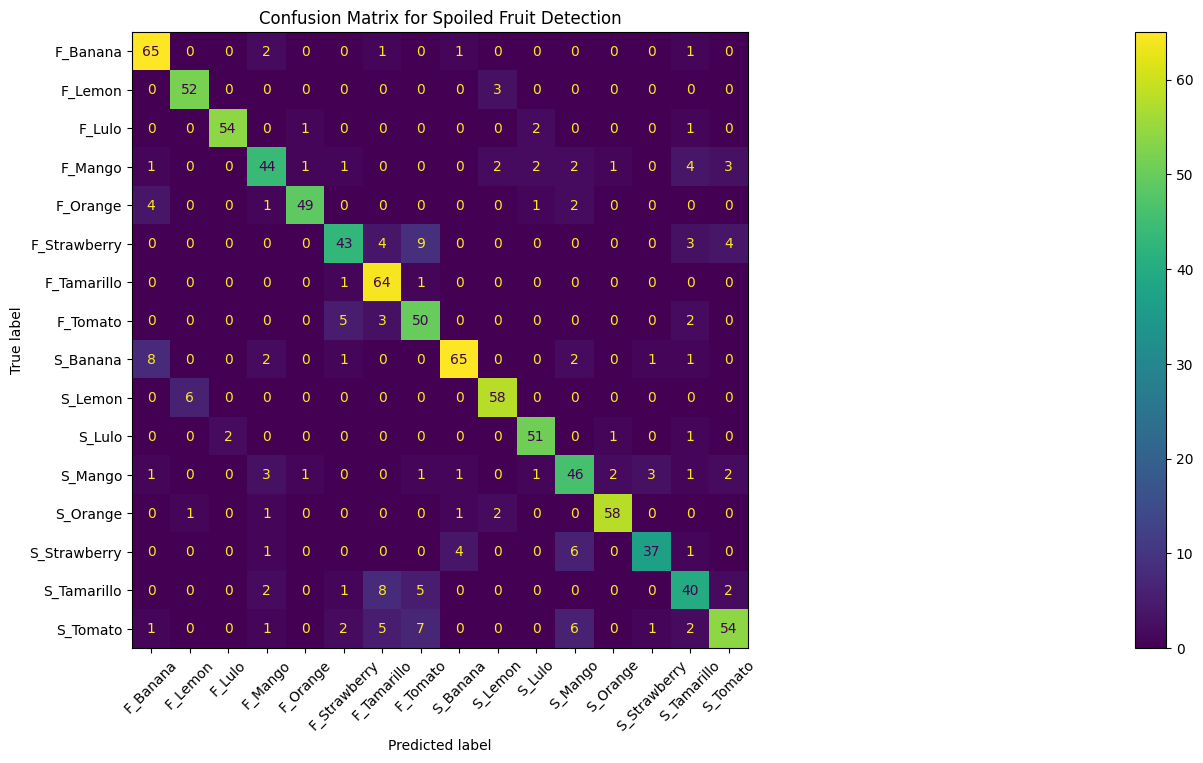

In [20]:
cm = confusion_matrix(true_labels,predicted_labels)
fig, ax = plt.subplots(figsize=(100, 8))
disp = ConfusionMatrixDisplay(cm,display_labels = dataset.classes)
disp.plot(ax=ax,xticks_rotation =45)
plt.title("Confusion Matrix for Spoiled Fruit Detection")
plt.show()

### 2. Transfer Learning (ResNet50)

In [21]:
class FreshnessClassifierResnet(nn.Module):
    def __init__(self,num_classes = 6):
        super().__init__()
        self.model = models.resnet50(weights = 'DEFAULT')

        in_features = self.model.fc.in_features

        for param in self.model.parameters():
            param.requires_grad= False 
            
        for param in self.model.layer4.parameters():
            param.requires_grad = True
            
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features,num_classes)
        )
    def forward(self,x):
        return self.model(x)

In [22]:
num_classes = len(dataset.classes)
resnet_model = FreshnessClassifierResnet(num_classes).to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()),lr = 0.002)
train_accuracies, val_accuracies = train_validate(resnet_model,criterion,optimizer,2)

Batch: 20 | Epoch: 1 | Loss: 0.37
Batch: 40 | Epoch: 1 | Loss: 0.10
Batch: 60 | Epoch: 1 | Loss: 0.07
Batch: 80 | Epoch: 1 | Loss: 0.07
Batch: 100 | Epoch: 1 | Loss: 0.10
Batch: 120 | Epoch: 1 | Loss: 0.14
Batch: 140 | Epoch: 1 | Loss: 0.09
Batch: 160 | Epoch: 1 | Loss: 0.22
Batch: 180 | Epoch: 1 | Loss: 0.02
Epoch: 1 | Average Training Loss: 0.17
Validation Accuracy: 99.57%
Batch: 20 | Epoch: 2 | Loss: 0.00
Batch: 40 | Epoch: 2 | Loss: 0.00
Batch: 60 | Epoch: 2 | Loss: 0.01
Batch: 80 | Epoch: 2 | Loss: 0.00
Batch: 100 | Epoch: 2 | Loss: 0.01
Batch: 120 | Epoch: 2 | Loss: 0.00
Batch: 140 | Epoch: 2 | Loss: 0.13
Batch: 160 | Epoch: 2 | Loss: 0.01
Batch: 180 | Epoch: 2 | Loss: 0.02
Epoch: 2 | Average Training Loss: 0.03
Validation Accuracy: 99.60%


In [23]:
# Saving the Resnet CNN model
torch.save(resnet_model.state_dict(),'./artifacts/resnet50_model.pth')

In [24]:
num_classes = len(dataset.classes)
trained_resnet_model = FreshnessClassifierResnet(num_classes =num_classes ).to(device)
trained_resnet_model.load_state_dict(torch.load("./artifacts/resnet50_model.pth",weights_only = False))

<All keys matched successfully>

In [27]:
true_labels, predicted_labels = [],[]
for images,labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    output = trained_resnet_model(images)
    _, predicted = torch.max(output.data,dim =1)
    true_labels.extend(labels.cpu().numpy())
    predicted_labels.extend(predicted.cpu().numpy())
else:
    print("All the labels are stored...")

All the labels are stored...


In [28]:
report = classification_report(true_labels,predicted_labels)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       0.98      1.00      0.99        55
           2       0.98      1.00      0.99        58
           3       1.00      0.98      0.99        61
           4       1.00      1.00      1.00        57
           5       1.00      0.98      0.99        63
           6       1.00      1.00      1.00        66
           7       1.00      1.00      1.00        60
           8       1.00      1.00      1.00        80
           9       1.00      1.00      1.00        64
          10       1.00      0.96      0.98        55
          11       0.98      1.00      0.99        62
          12       1.00      0.98      0.99        63
          13       0.94      1.00      0.97        49
          14       1.00      0.98      0.99        58
          15       1.00      1.00      1.00        79

    accuracy                           0.99      1000
   macro avg       0.99   

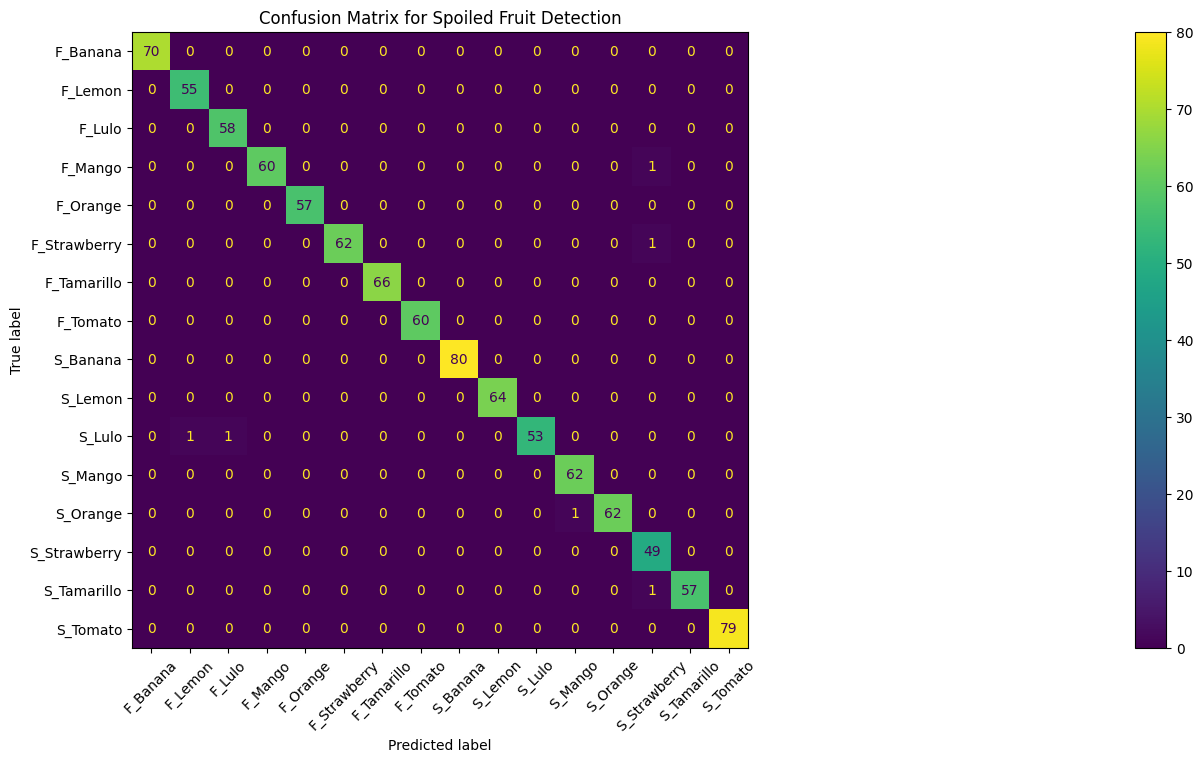

In [29]:
cm = confusion_matrix(true_labels,predicted_labels)
fig, ax = plt.subplots(figsize=(100, 8))
disp = ConfusionMatrixDisplay(cm,display_labels = dataset.classes)
disp.plot(ax=ax,xticks_rotation =45)
plt.title("Confusion Matrix for Spoiled Fruit Detection")
plt.show()